# Arm Mask+Depth Refinement (640×480) + KNN Residue Filter — Colab / Kaggle

Combined pipeline, GPU-optimized, reads the `supphasansaithong/mani-recognition` Kaggle dataset via `kagglehub`:

- **Stage A** — batched 640×480 inference with `JointToMaskDepthNet`, GPU affine-grid refinement, occlusion-aware depth subtraction, threaded disk I/O.
- **Stage B** — vectorized KNN-graph cluster filter keeps the largest connected component of the subtracted depth (= the object).

> Tip: Runtime → Change runtime type → **GPU** before running.

## 0. Environment setup — Kaggle dataset, deps, GPU

In [ ]:
IN_COLAB = False
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    pass
print('In Colab:', IN_COLAB)

In Colab: True


In [ ]:
# Install missing dependencies (Colab has most already; kagglehub may need install).
import importlib, subprocess, sys

def _ensure(pkg, import_name=None):
    try:
        importlib.import_module(import_name or pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

for pkg, mod in [
    ('kagglehub', 'kagglehub'),
    ('pyyaml', 'yaml'),
    ('opencv-python-headless', 'cv2'),
    ('scikit-learn', 'sklearn'),
    ('scipy', 'scipy'),
    ('tqdm', 'tqdm'),
    ('open3d', 'open3d'),
]:
    _ensure(pkg, mod)

In [ ]:
import torch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('torch :', torch.__version__)
print('device:', DEVICE)
if DEVICE == 'cuda':
    print('gpu   :', torch.cuda.get_device_name(0))

torch : 2.10.0+cu128
device: cuda
gpu   : Tesla T4


### Download the Kaggle dataset

Copies `supphasansaithong/mani-recognition` to `/content`. On Kaggle notebooks the dataset is often already attached at `/kaggle/input/...`; in that case this cell still works but is essentially a no-op. On Colab you need Kaggle credentials configured — `kagglehub` will prompt or read `~/.kaggle/kaggle.json` automatically.

In [ ]:
import kagglehub
import shutil
from pathlib import Path

KAGGLE_DATASET = 'supphasansaithong/mani-recognition'
TARGET_PATH    = '/content' if IN_COLAB else '/kaggle/working/mani-recognition'

path = kagglehub.dataset_download(KAGGLE_DATASET)
print('Path to dataset files:', path)

Path(TARGET_PATH).mkdir(parents=True, exist_ok=True)
shutil.copytree(path, TARGET_PATH, dirs_exist_ok=True)
print(f'Files copied to: {TARGET_PATH}')

100%|██████████| 132M/132M [00:01<00:00, 115MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/supphasansaithong/mani-recognition/versions/3
Files copied to: /content


In [ ]:
# Quick look at what was downloaded so we can set the paths correctly below.
import os

def _listdir_safe(p, limit=40):
    try:
        return sorted(os.listdir(p))[:limit]
    except FileNotFoundError:
        return []

print('Top level:', _listdir_safe(TARGET_PATH))
for name in _listdir_safe(TARGET_PATH):
    sub = os.path.join(TARGET_PATH, name)
    if os.path.isdir(sub):
        print(f'  {name}/ ->', _listdir_safe(sub, 20))

Top level: ['.config', 'checkpoints_multisession_640x480', 'requirements.txt', 'sample_data', 'session_test', 'session_train1', 'session_train2']
  .config/ -> ['.last_opt_in_prompt.yaml', '.last_survey_prompt.yaml', '.last_update_check.json', 'active_config', 'config_sentinel', 'configurations', 'default_configs.db', 'gce', 'hidden_gcloud_config_universe_descriptor_data_cache_configs.db', 'logs']
  checkpoints_multisession_640x480/ -> ['best_multisession_640x480.pth', 'latest_multisession_640x480.pth', 'training_history_multisession_640x480.json']
  sample_data/ -> ['README.md', 'anscombe.json', 'california_housing_test.csv', 'california_housing_train.csv', 'mnist_test.csv', 'mnist_train_small.csv']
  session_test/ -> ['session_test']
  session_train1/ -> ['session_train1']
  session_train2/ -> ['session_train2']


## 1. User settings

Set `SESSION_DIR` to the folder that contains `meta.txt` + `crop/` (from the Kaggle dataset), and `CHECKPOINT_PATH` to the 640×480 checkpoint inside the same download.

Defaults below assume the dataset root copied to `TARGET_PATH` contains a `session*` folder and a `checkpoints_multisession_640x480/` folder. Adjust if the dataset layout differs (inspect output of the cell above).

In [ ]:
import os, glob

SESSION_DIR = '/content/session_test/session_test'
CHECKPOINT_PATH = '/content/checkpoints_multisession_640x480/best_multisession_640x480.pth'

DATASET_ROOT = os.path.join(SESSION_DIR, 'crop')
META_PATH    = os.path.join(SESSION_DIR, 'meta.txt')

OUTPUT_BASE = SESSION_DIR if os.access(SESSION_DIR, os.W_OK) else '/kaggle/working/mani_outputs'
STAGE_A_OUTPUT_DIR = os.path.join(OUTPUT_BASE, 'test_outputs_mask_depth_refined_640x480')
STAGE_B_OUTPUT_DIR = os.path.join(OUTPUT_BASE, 'test_outputs_knn_filtered')

print('SESSION_DIR        :', SESSION_DIR)
print('META_PATH          :', META_PATH, ' exists=', os.path.exists(META_PATH))
print('DATASET_ROOT       :', DATASET_ROOT, ' exists=', os.path.isdir(DATASET_ROOT))
print('CHECKPOINT_PATH    :', CHECKPOINT_PATH, ' exists=', os.path.exists(CHECKPOINT_PATH))
print('STAGE_A_OUTPUT_DIR :', STAGE_A_OUTPUT_DIR)
print('STAGE_B_OUTPUT_DIR :', STAGE_B_OUTPUT_DIR)

SESSION_DIR        : /content/session_test/session_test
META_PATH          : /content/session_test/session_test/meta.txt  exists= True
DATASET_ROOT       : /content/session_test/session_test/crop  exists= True
CHECKPOINT_PATH    : /content/checkpoints_multisession_640x480/best_multisession_640x480.pth  exists= True
STAGE_A_OUTPUT_DIR : /content/session_test/session_test/test_outputs_mask_depth_refined_640x480
STAGE_B_OUTPUT_DIR : /content/session_test/session_test/test_outputs_knn_filtered


In [ ]:
# ------------------------------------------------------------------
# Stage A — 640x480 model + refinement
# ------------------------------------------------------------------
OUT_H        = 480
OUT_W        = 640
DECODER_SIZE = 256  # must match what the checkpoint was trained with

THRESHOLD = 0.5
SUBTRACT_MODE = 'depth_minus'   # or 'zero_out'

DEPTH_NORM_FALLBACK_MAX_MM = 1000.0
SELECTED_JOINTS = None  # None -> use checkpoint-stored joints

ENABLE_REFINEMENT = True
OBS_MASK_MODE = 'full_nonzero'  # or 'close_to_pred'

# 640x480-scaled search ranges
COARSE_DX    = list(range(-50, 51, 10))
COARSE_DY    = list(range(-40, 41, 10))
COARSE_THETA = [-8, -6, -4, -2, 0, 2, 4, 6, 8]
COARSE_SCALE = [1.0]

USE_FINE_REFINEMENT = True
FINE_DXY_RADIUS   = 8
FINE_THETA_RADIUS = 2.0
FINE_THETA_STEP   = 0.5
FINE_SCALE        = [1.0]

LAMBDA_MASK   = 1.0
LAMBDA_DEPTH  = 0.5
LAMBDA_CENTER = 0.05

MIN_IOU_IMPROVEMENT_TO_ACCEPT = 0.0

# GPU batch sizes
INFER_BATCH = 64    # model forward pass
WARP_CHUNK  = 256   # affine candidates per GPU chunk (lower if OOM)

# ------------------------------------------------------------------
# Stage B — KNN residue filter
# ------------------------------------------------------------------
K_NEIGHBORS      = 5
MAX_DIST_PX      = 4.0
SAVE_COMPARISONS = True
PREVIEW_SAMPLES  = 6

## 2. Imports

In [ ]:
from __future__ import annotations

import csv
import math
from concurrent.futures import ThreadPoolExecutor
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import cv2
import yaml
import numpy as np
from PIL import Image
import open3d as o3d

import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import scipy.sparse as sp
import scipy.sparse.csgraph as csgraph
from sklearn.neighbors import NearestNeighbors

%matplotlib inline

## 3. Shared utilities (rectangular-aware resize)

In [ ]:
def safe_float(x) -> float:
    try:
        v = float(x)
        if math.isnan(v) or math.isinf(v):
            return 0.0
        return v
    except Exception:
        return 0.0


def flatten_matrix(mat, expected_shape=(4, 4)) -> List[float]:
    if mat is None:
        return [0.0] * (expected_shape[0] * expected_shape[1])
    arr = np.asarray(mat, dtype=np.float32)
    if arr.shape != expected_shape:
        out = np.zeros(expected_shape, dtype=np.float32)
        h = min(expected_shape[0], arr.shape[0]); w = min(expected_shape[1], arr.shape[1])
        out[:h, :w] = arr[:h, :w]
        arr = out
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    return arr.reshape(-1).tolist()


def load_yaml_meta(meta_path: str) -> Dict:
    with open(meta_path, 'r', encoding='utf-8') as f:
        text = f.read()
    text = text.replace(': nan', ': .nan')
    data = yaml.safe_load(text)
    if not isinstance(data, dict) or 'captures' not in data or not isinstance(data['captures'], list):
        raise ValueError(f'Bad meta file: {meta_path}')
    return data


def resize_nearest(img, out_w: int, out_h: int) -> np.ndarray:
    return cv2.resize(img, (out_w, out_h), interpolation=cv2.INTER_NEAREST).astype(np.float32)


def resize_linear(img, out_w: int, out_h: int) -> np.ndarray:
    return cv2.resize(img, (out_w, out_h), interpolation=cv2.INTER_LINEAR).astype(np.float32)


def depth_to_binary_mask(depth_img: np.ndarray) -> np.ndarray:
    if depth_img.ndim == 3:
        depth_img = depth_img[..., 0]
    return (depth_img > 0).astype(np.float32)


def save_mask_png(mask01, out_path):
    Image.fromarray((np.clip(mask01, 0.0, 1.0) * 255).astype(np.uint8)).save(out_path)


def save_depth_vis(depth01, out_path):
    Image.fromarray((np.clip(depth01, 0.0, 1.0) * 255).astype(np.uint8)).save(out_path)


def save_raw_depth_png(depth_raw, out_path):
    if depth_raw.dtype not in [np.uint8, np.uint16]:
        depth_raw = depth_raw.astype(np.uint16 if depth_raw.max() > 255 else np.uint8)
    Image.fromarray(depth_raw).save(out_path)


def normalize_depth(depth_img, mode: str, global_max_mm: float) -> np.ndarray:
    depth = depth_img.astype(np.float32)
    if depth.ndim == 3:
        depth = depth[..., 0]
    valid = depth > 0
    out = np.zeros_like(depth, dtype=np.float32)
    if not np.any(valid):
        return out
    if mode == 'per_image':
        dmax = depth[valid].max()
        if dmax > 0:
            out[valid] = depth[valid] / dmax
    elif mode == 'global':
        out[valid] = depth[valid] / float(global_max_mm)
        out = np.clip(out, 0.0, 1.0)
    else:
        raise ValueError(f'Unknown depth norm mode: {mode}')
    return out


def denormalize_depth(depth01, ref_depth_raw, mode, global_max_mm):
    ref = ref_depth_raw.astype(np.float32); valid = ref > 0
    out = np.zeros_like(depth01, dtype=np.float32)
    if mode == 'per_image':
        if np.any(valid):
            out = depth01 * ref[valid].max()
    elif mode == 'global':
        out = depth01 * float(global_max_mm)
    else:
        raise ValueError(f'Unknown depth norm mode: {mode}')
    return out


def make_overlay(gt, pred):
    gt_b = gt.astype(bool); pr_b = pred.astype(bool)
    tp = gt_b & pr_b; fn = gt_b & (~pr_b); fp = (~gt_b) & pr_b
    ov = np.zeros((gt.shape[0], gt.shape[1], 3), dtype=np.uint8)
    ov[tp] = [255, 255, 255]; ov[fn] = [255, 0, 0]; ov[fp] = [0, 255, 0]
    return ov


def save_color_png(img_rgb, out_path):
    Image.fromarray(img_rgb.astype(np.uint8)).save(out_path)


def add_label(img, text):
    img = img.copy()
    if len(img.shape) == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    cv2.rectangle(img, (0, 0), (200, 24), (0, 0, 0), -1)
    cv2.putText(img, text, (5, 18), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1, cv2.LINE_AA)
    return img

## 4. Model — `JointToMaskDepthNet` (640×480)

In [ ]:
class CoordConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, **kwargs):
        super().__init__()
        self.conv = nn.Conv2d(in_channels + 2, out_channels, **kwargs)

    def forward(self, x):
        b, _, h, w = x.shape
        ys = torch.linspace(-1.0, 1.0, h, device=x.device).view(1, 1, h, 1).expand(b, 1, h, w)
        xs = torch.linspace(-1.0, 1.0, w, device=x.device).view(1, 1, 1, w).expand(b, 1, h, w)
        return self.conv(torch.cat([x, ys, xs], dim=1))


class JointToMaskDepthNet(nn.Module):
    """MLP -> CoordConv decoder -> (out_h, out_w) mask + depth.

    Decoder upsamples 8x8 -> decoder_size x decoder_size, then F.interpolate
    stretches to (out_h, out_w).
    """
    def __init__(self, input_dim, out_h=480, out_w=640, decoder_size=256):
        super().__init__()
        assert decoder_size in (64, 128, 256, 512)
        self.out_h, self.out_w, self.decoder_size = out_h, out_w, decoder_size

        self.mlp = nn.Sequential(
            nn.Linear(input_dim, 256), nn.ReLU(inplace=True),
            nn.Linear(256, 512), nn.ReLU(inplace=True),
            nn.Linear(512, 8 * 8 * 128), nn.ReLU(inplace=True),
        )

        layers: List[nn.Module] = []
        in_ch, cur_size = 128, 8
        while cur_size < decoder_size:
            out_ch = max(in_ch // 2, 16)
            layers += [
                nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
                CoordConv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            ]
            in_ch = out_ch; cur_size *= 2
        self.shared_decoder = nn.Sequential(*layers)

        self.mask_head = CoordConv2d(in_ch, 1, kernel_size=1)
        self.depth_head = nn.Sequential(
            CoordConv2d(in_ch, in_ch, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(in_ch, 1, kernel_size=1), nn.Sigmoid(),
        )

    def forward(self, x):
        b = x.shape[0]
        z = self.mlp(x).view(b, 128, 8, 8)
        feat = self.shared_decoder(z)
        mask_logits = F.interpolate(self.mask_head(feat),  size=(self.out_h, self.out_w), mode='bilinear', align_corners=False)
        depth_pred  = F.interpolate(self.depth_head(feat), size=(self.out_h, self.out_w), mode='bilinear', align_corners=False)
        return mask_logits, depth_pred

## 5. Feature builder, metrics, subtraction

In [ ]:
def build_feature_vector(capture, selected_joints, use_velocities=False, use_efforts=False,
                         use_t_cam_to_ee=False, use_t_base_to_ee=False) -> np.ndarray:
    joint_names      = capture.get('joint_names', [])
    joint_positions  = capture.get('joint_positions', [])
    joint_velocities = capture.get('joint_velocities', [])
    joint_efforts    = capture.get('joint_efforts', [])
    name_to_idx = {n: i for i, n in enumerate(joint_names)}
    feats: List[float] = []

    def _pick(src, jn):
        idx = name_to_idx.get(jn)
        return safe_float(src[idx]) if idx is not None and idx < len(src) else 0.0

    for jn in selected_joints: feats.append(_pick(joint_positions, jn))
    if use_velocities:
        for jn in selected_joints: feats.append(_pick(joint_velocities, jn))
    if use_efforts:
        for jn in selected_joints: feats.append(_pick(joint_efforts, jn))
    if use_t_cam_to_ee:  feats.extend(flatten_matrix(capture.get('T_cam_to_ee')))
    if use_t_base_to_ee: feats.extend(flatten_matrix(capture.get('T_base_to_ee')))
    return np.asarray(feats, dtype=np.float32)


@dataclass
class FrameMetrics:
    seq: int; filename: str
    raw_iou: float; refined_iou: float
    raw_dice: float; refined_dice: float
    raw_depth_mae: float; refined_depth_mae: float
    pixel_acc: float; precision: float; recall: float
    align_dx: float; align_dy: float; align_theta: float; align_scale: float; align_loss: float


def compute_mask_metrics(pred, gt, eps=1e-8):
    pb, gb = pred.astype(bool), gt.astype(bool)
    tp = np.logical_and(pb, gb).sum(); tn = np.logical_and(~pb, ~gb).sum()
    fp = np.logical_and(pb, ~gb).sum(); fn = np.logical_and(~pb, gb).sum()
    iou = tp / (tp + fp + fn + eps); dice = (2.0 * tp) / (2.0 * tp + fp + fn + eps)
    return {'iou': float(iou), 'dice': float(dice),
            'pixel_acc': float((tp + tn) / (tp + tn + fp + fn + eps)),
            'precision': float(tp / (tp + fp + eps)),
            'recall':    float(tp / (tp + fn + eps))}


def compute_depth_mae(pred, gt, gt_mask):
    valid = gt_mask > 0.5
    return 0.0 if valid.sum() == 0 else float(np.abs(pred[valid] - gt[valid]).mean())


def subtract_predicted_arm(original_depth_raw, pred_mask01, pred_depth01,
                           depth_norm_mode, depth_max_mm, tolerance_mm=30.0):
    original = original_depth_raw.astype(np.float32)
    pred_mask_bin = pred_mask01 > 0.5
    pred_depth_raw = denormalize_depth(pred_depth01, original_depth_raw, depth_norm_mode, depth_max_mm).astype(np.float32)
    out = original.copy()
    valid_obs = original > 0; valid_pred = pred_mask_bin & (pred_depth_raw > 0)
    visible_arm = valid_obs & valid_pred & (pred_depth_raw <= original + tolerance_mm)
    out[visible_arm] = 0.0
    return np.clip(out, 0, 65535).astype(np.uint16) if original_depth_raw.dtype == np.uint16 \
           else np.clip(out, 0, 255).astype(np.uint8)

## 6. Refinement — GPU-batched affine search

Builds all `(dx, dy, theta, scale)` combos, warps them on GPU in `WARP_CHUNK`-sized batches using `affine_grid` + `grid_sample`, scores online so no (N, H, W) intermediate is ever allocated.

In [ ]:
def compute_iou(a, b, eps=1e-8):
    a = a.astype(bool); b = b.astype(bool)
    inter = np.logical_and(a, b).sum(); union = np.logical_or(a, b).sum()
    return float(inter / (union + eps))


def warp_pair(mask, depth, dx, dy, theta_deg, scale=1.0):
    h, w = mask.shape
    M = cv2.getRotationMatrix2D((w / 2.0, h / 2.0), theta_deg, scale)
    M[0, 2] += dx; M[1, 2] += dy
    return None, None, M  # only the M is used by callers after GPU search


def build_observation_mask(obs_depth01, raw_pred_mask, mode='full_nonzero'):
    full = (obs_depth01 > 0).astype(np.uint8)
    if mode == 'full_nonzero':
        return full
    if mode == 'close_to_pred':
        roi = cv2.dilate(raw_pred_mask.astype(np.uint8), np.ones((43, 43), np.uint8), iterations=1)
        return (full * roi).astype(np.uint8)
    raise ValueError(f'Unknown OBS_MASK_MODE: {mode}')


def _build_affine_batch(combos, H, W, device):
    """Convert (dx, dy, theta_deg, scale) to normalized torch affine matrices."""
    N  = len(combos)
    sx = 2.0 / (W - 1)
    sy = 2.0 / (H - 1)
    r  = float(H - 1) / float(W - 1)
    thetas = torch.zeros(N, 2, 3, dtype=torch.float32)
    for i, (dx, dy, theta_deg, scale) in enumerate(combos):
        a = math.radians(theta_deg)
        cos_a = scale * math.cos(a); sin_a = scale * math.sin(a)
        thetas[i] = torch.tensor([
            [ cos_a,       r * sin_a,    sx * dx],
            [-sin_a / r,   cos_a,        sy * dy],
        ])
    return thetas.to(device)


def _search_alignment(pred_mask, pred_depth, obs_mask, obs_depth,
                     dx_values, dy_values, theta_values, scale_values):
    H, W = pred_mask.shape
    combos = [(dx, dy, t, s)
              for dx in dx_values for dy in dy_values
              for t in theta_values for s in scale_values]
    N = len(combos)

    thetas  = _build_affine_batch(combos, H, W, DEVICE)
    mask_t  = torch.from_numpy(pred_mask.astype(np.float32)).to(DEVICE).unsqueeze(0).unsqueeze(0)
    depth_t = torch.from_numpy(pred_depth.astype(np.float32)).to(DEVICE).unsqueeze(0).unsqueeze(0)
    om_gpu  = torch.from_numpy(obs_mask.astype(np.float32)).to(DEVICE)
    od_gpu  = torch.from_numpy(obs_depth.astype(np.float32)).to(DEVICE)
    om_b    = om_gpu > 0.5

    ys_gpu = torch.arange(H, dtype=torch.float32, device=DEVICE).view(H, 1)
    xs_gpu = torch.arange(W, dtype=torch.float32, device=DEVICE).view(1, W)
    has_obs = bool(om_b.float().sum() > 0)
    if has_obs:
        om_cnt = om_b.float().sum().clamp(min=1)
        om_cx = (om_b.float() * xs_gpu).sum() / om_cnt
        om_cy = (om_b.float() * ys_gpu).sum() / om_cnt
    else:
        om_cx = om_cy = torch.tensor(0.0, device=DEVICE)

    best_loss = float('inf'); best_i_abs = 0
    best_wm_np = None; best_wd_np = None
    best_iou = 0.0; best_dmae = 1e6; best_cp = 1e6

    for start in range(0, N, WARP_CHUNK):
        end = min(start + WARP_CHUNK, N); chunk = end - start
        grid = F.affine_grid(thetas[start:end], (chunk, 1, H, W), align_corners=True)
        wm_chunk = F.grid_sample(mask_t.expand(chunk, -1, -1, -1),  grid,
                                  mode='nearest',  padding_mode='zeros', align_corners=True)
        wd_chunk = F.grid_sample(depth_t.expand(chunk, -1, -1, -1), grid,
                                  mode='bilinear', padding_mode='zeros', align_corners=True)
        wm = wm_chunk[:, 0]; wd = wd_chunk[:, 0]
        wm_b = wm > 0.5
        wd = wd * wm_b.float()

        inter = (wm_b & om_b.unsqueeze(0)).float().sum(dim=(1, 2))
        union = (wm_b | om_b.unsqueeze(0)).float().sum(dim=(1, 2))
        iou = inter / (union + 1e-8)

        overlap = wm_b & om_b.unsqueeze(0)
        ov_cnt = overlap.float().sum(dim=(1, 2))
        depth_mae = ((wd - od_gpu.unsqueeze(0)).abs() * overlap.float()).sum(dim=(1, 2)) / ov_cnt.clamp(min=1)
        depth_mae = torch.where(ov_cnt > 0, depth_mae, torch.full_like(depth_mae, 1e6))

        wm_cnt = wm_b.float().sum(dim=(1, 2)).clamp(min=1)
        wm_cx = (wm_b.float() * xs_gpu.unsqueeze(0)).sum(dim=(1, 2)) / wm_cnt
        wm_cy = (wm_b.float() * ys_gpu.unsqueeze(0)).sum(dim=(1, 2)) / wm_cnt
        cp = torch.sqrt((wm_cx - om_cx) ** 2 + (wm_cy - om_cy) ** 2)
        has_wm = wm_b.float().sum(dim=(1, 2)) > 0
        cp = torch.full_like(cp, 1e6) if not has_obs else torch.where(has_wm, cp, torch.full_like(cp, 1e6))

        loss = LAMBDA_MASK * (1.0 - iou) + LAMBDA_DEPTH * depth_mae + LAMBDA_CENTER * cp / max(H, W)
        local_best = int(loss.argmin()); local_loss = loss[local_best].item()
        if local_loss < best_loss:
            best_loss = local_loss; best_i_abs = start + local_best
            best_wm_np = (wm[local_best] > 0.5).byte().cpu().numpy()
            best_wd_np = wd[local_best].cpu().numpy()
            best_iou = float(iou[local_best].item())
            best_dmae = float(depth_mae[local_best].item())
            best_cp = float(cp[local_best].item())

    dx, dy, t, s = combos[best_i_abs]
    _, _, M = warp_pair(pred_mask, pred_depth, dx, dy, t, s)
    return {'loss': best_loss, 'iou': best_iou, 'depth_mae': best_dmae, 'center_penalty': best_cp,
            'dx': float(dx), 'dy': float(dy), 'theta': float(t), 'scale': float(s),
            'mask': best_wm_np, 'depth': best_wd_np, 'M': M}


def refine_alignment(pred_mask, pred_depth, obs_mask, obs_depth):
    coarse = _search_alignment(pred_mask, pred_depth, obs_mask, obs_depth,
                               COARSE_DX, COARSE_DY, COARSE_THETA, COARSE_SCALE)
    if not USE_FINE_REFINEMENT:
        return coarse
    bdx = int(round(coarse['dx'])); bdy = int(round(coarse['dy'])); bt = float(coarse['theta'])
    fine_dx = range(bdx - FINE_DXY_RADIUS, bdx + FINE_DXY_RADIUS + 1, 1)
    fine_dy = range(bdy - FINE_DXY_RADIUS, bdy + FINE_DXY_RADIUS + 1, 1)
    fine_theta = []
    t = bt - FINE_THETA_RADIUS
    while t <= bt + FINE_THETA_RADIUS + 1e-8:
        fine_theta.append(round(t, 3)); t += FINE_THETA_STEP
    fine = _search_alignment(pred_mask, pred_depth, obs_mask, obs_depth,
                             fine_dx, fine_dy, fine_theta, FINE_SCALE)
    return fine if fine['loss'] < coarse['loss'] else coarse

## 7. Stage A — batched inference, refinement, subtraction

In [ ]:
def _load_frame_data(args):
    cap, dataset_root, out_w, out_h, depth_norm_mode, depth_max_mm = args
    depth_png = cap.get('depth_png', '')
    depth_path = os.path.join(dataset_root, depth_png)
    if not depth_png or not os.path.exists(depth_path):
        return None
    depth_raw = np.array(Image.open(depth_path))
    if depth_raw.ndim == 3:
        depth_raw = depth_raw[..., 0]
    gt_mask    = resize_nearest(depth_to_binary_mask(depth_raw), out_w, out_h).astype(np.uint8)
    gt_depth01 = resize_nearest(normalize_depth(depth_raw, depth_norm_mode, depth_max_mm), out_w, out_h)
    return depth_raw, gt_mask, gt_depth01


def _save_frame_outputs(fname,
                        pred_mask_dir, pred_depth_dir, gt_mask_dir,
                        subtract_dir, compare_dir, refined_overlay_dir,
                        refined_pred_mask, gt_mask, refined_pred_depth,
                        subtracted_depth_raw, gt_depth01,
                        raw_pred_mask, raw_pred_depth,
                        depth_norm_mode, depth_max_mm):
    save_mask_png(refined_pred_mask.astype(np.float32),  os.path.join(pred_mask_dir,  fname))
    save_mask_png(gt_mask.astype(np.float32),            os.path.join(gt_mask_dir,    fname))
    save_depth_vis(refined_pred_depth,                   os.path.join(pred_depth_dir, fname))
    save_raw_depth_png(subtracted_depth_raw,             os.path.join(subtract_dir,   fname))

    raw_overlay     = make_overlay(gt_mask, raw_pred_mask)
    refined_overlay = make_overlay(gt_mask, refined_pred_mask)
    save_color_png(refined_overlay, os.path.join(refined_overlay_dir, fname))

    gt_mask_vis            = (gt_mask * 255).astype(np.uint8)
    raw_pred_mask_vis      = (raw_pred_mask * 255).astype(np.uint8)
    refined_pred_mask_vis  = (refined_pred_mask * 255).astype(np.uint8)
    gt_depth_vis           = (np.clip(gt_depth01,         0.0, 1.0) * 255).astype(np.uint8)
    raw_pred_depth_vis     = (np.clip(raw_pred_depth,     0.0, 1.0) * 255).astype(np.uint8)
    refined_pred_depth_vis = (np.clip(refined_pred_depth, 0.0, 1.0) * 255).astype(np.uint8)

    sub_depth01 = normalize_depth(subtracted_depth_raw.astype(np.float32), depth_norm_mode, depth_max_mm)
    sub_depth_vis = (np.clip(sub_depth01, 0.0, 1.0) * 255).astype(np.uint8)

    top = np.concatenate([
        add_label(cv2.cvtColor(gt_mask_vis,           cv2.COLOR_GRAY2RGB), 'GT Mask'),
        add_label(cv2.cvtColor(raw_pred_mask_vis,     cv2.COLOR_GRAY2RGB), 'Pred Raw'),
        add_label(raw_overlay,                                             'Overlay Raw'),
        add_label(cv2.cvtColor(refined_pred_mask_vis, cv2.COLOR_GRAY2RGB), 'Pred Refined'),
        add_label(refined_overlay,                                         'Overlay Refined'),
    ], axis=1)
    bottom = np.concatenate([
        add_label(cv2.cvtColor(gt_depth_vis,            cv2.COLOR_GRAY2RGB), 'GT Depth'),
        add_label(cv2.cvtColor(raw_pred_depth_vis,      cv2.COLOR_GRAY2RGB), 'Depth Raw'),
        add_label(cv2.cvtColor(refined_pred_depth_vis,  cv2.COLOR_GRAY2RGB), 'Depth Refined'),
        add_label(cv2.cvtColor(sub_depth_vis,           cv2.COLOR_GRAY2RGB), 'Subtract'),
        add_label(np.zeros_like(refined_overlay),                            'Empty'),
    ], axis=1)
    Image.fromarray(np.concatenate([top, bottom], axis=0)).save(os.path.join(compare_dir, fname))


def run_stage_a():
    os.makedirs(STAGE_A_OUTPUT_DIR, exist_ok=True)
    pred_mask_dir       = os.path.join(STAGE_A_OUTPUT_DIR, 'pred_masks')
    pred_depth_dir      = os.path.join(STAGE_A_OUTPUT_DIR, 'pred_depth')
    gt_mask_dir         = os.path.join(STAGE_A_OUTPUT_DIR, 'gt_masks')
    subtract_dir        = os.path.join(STAGE_A_OUTPUT_DIR, 'subtracted_depth_raw')
    compare_dir         = os.path.join(STAGE_A_OUTPUT_DIR, 'comparisons')
    refined_overlay_dir = os.path.join(STAGE_A_OUTPUT_DIR, 'refined_overlays')
    for d in [pred_mask_dir, pred_depth_dir, gt_mask_dir,
              subtract_dir, compare_dir, refined_overlay_dir]:
        os.makedirs(d, exist_ok=True)

    meta = load_yaml_meta(META_PATH)
    captures = meta['captures']
    if not captures:
        raise ValueError('No captures found in meta.txt')

    ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    selected_joints  = SELECTED_JOINTS or ckpt['selected_joints']
    use_velocities   = ckpt.get('use_velocities', False)
    use_efforts      = ckpt.get('use_efforts', False)
    use_t_cam_to_ee  = ckpt.get('use_t_cam_to_ee', False)
    use_t_base_to_ee = ckpt.get('use_t_base_to_ee', False)
    input_dim        = ckpt['input_dim']
    depth_norm_mode  = ckpt.get('depth_norm_mode', 'per_image')
    depth_max_mm     = ckpt.get('depth_max_mm', DEPTH_NORM_FALLBACK_MAX_MM)
    out_h            = ckpt.get('out_h', OUT_H)
    out_w            = ckpt.get('out_w', OUT_W)
    decoder_size     = ckpt.get('decoder_size', DECODER_SIZE)

    model = JointToMaskDepthNet(input_dim=input_dim, out_h=out_h, out_w=out_w,
                                decoder_size=decoder_size).to(DEVICE)
    model.load_state_dict(ckpt['model_state_dict']); model.eval()

    print(f'Loaded checkpoint : {CHECKPOINT_PATH}')
    print(f'Output resolution : {out_w}x{out_h}')
    print(f'Decoder size      : {decoder_size}')
    print(f'Using joints      : {selected_joints}')
    print(f'Number of frames  : {len(captures)}')
    print(f'Depth norm mode   : {depth_norm_mode}')
    print(f'Refinement enabled: {ENABLE_REFINEMENT}')
    print(f'Observation mode  : {OBS_MASK_MODE}')
    print(f'Warp chunk size   : {WARP_CHUNK}')
    print(f'Infer batch size  : {INFER_BATCH}')

    # --- batched model inference --------------------------------------------
    all_feats: List[np.ndarray] = []
    for cap in captures:
        feat = build_feature_vector(cap, selected_joints, use_velocities, use_efforts,
                                    use_t_cam_to_ee, use_t_base_to_ee)
        if feat.shape[0] != input_dim:
            raise ValueError(f"Input dim mismatch seq={cap.get('seq', -1)}: {feat.shape[0]} vs {input_dim}")
        all_feats.append(feat)

    pred_mask_probs_list, pred_depth01s_list = [], []
    with torch.no_grad():
        for start in tqdm(range(0, len(all_feats), INFER_BATCH), desc='Inference'):
            batch = torch.from_numpy(np.stack(all_feats[start:start + INFER_BATCH])).float().to(DEVICE)
            ml, dp = model(batch)
            pred_mask_probs_list.append(torch.sigmoid(ml)[:, 0].cpu().numpy())
            pred_depth01s_list.append(dp[:, 0].cpu().numpy())
    pred_mask_probs_all = np.concatenate(pred_mask_probs_list, axis=0)
    pred_depth01s_all   = np.concatenate(pred_depth01s_list,   axis=0)
    print(f'Batched inference done ({len(all_feats)} frames, batch={INFER_BATCH})')

    rows: List[FrameMetrics] = []
    save_futures = []
    load_args = [(cap, DATASET_ROOT, out_w, out_h, depth_norm_mode, depth_max_mm) for cap in captures]

    with ThreadPoolExecutor(max_workers=4) as io_pool, \
         ThreadPoolExecutor(max_workers=4) as save_pool:

        futures = [io_pool.submit(_load_frame_data, a) for a in load_args]

        for idx, (cap, future) in enumerate(tqdm(list(zip(captures, futures)), desc='Refinement')):
            loaded = future.result()
            if loaded is None:
                print(f"[WARN] Missing or unreadable depth for seq={cap.get('seq', -1)}"); continue
            depth_raw, gt_mask, gt_depth01 = loaded
            seq       = int(cap.get('seq', -1))
            depth_png = cap.get('depth_png', '')

            pred_mask_prob = pred_mask_probs_all[idx]
            pred_depth01   = pred_depth01s_all[idx]
            raw_pred_mask  = (pred_mask_prob > THRESHOLD).astype(np.uint8)
            raw_pred_depth = pred_depth01.copy()
            raw_pred_depth[raw_pred_mask == 0] = 0.0

            obs_mask  = build_observation_mask(gt_depth01, raw_pred_mask, OBS_MASK_MODE)
            obs_depth = gt_depth01.astype(np.float32)

            raw_m         = compute_mask_metrics(raw_pred_mask, gt_mask)
            raw_depth_mae = compute_depth_mae(raw_pred_depth, gt_depth01, gt_mask)

            refined_pred_mask, refined_pred_depth = raw_pred_mask.copy(), raw_pred_depth.copy()
            best_align = {'dx': 0.0, 'dy': 0.0, 'theta': 0.0, 'scale': 1.0, 'loss': 0.0,
                          'iou': raw_m['iou'], 'depth_mae': raw_depth_mae}

            if ENABLE_REFINEMENT:
                cand = refine_alignment(raw_pred_mask.astype(np.uint8), raw_pred_depth.astype(np.float32),
                                        obs_mask.astype(np.uint8), obs_depth.astype(np.float32))
                raw_vs_obs_iou = compute_iou(raw_pred_mask, obs_mask)
                if cand['iou'] >= raw_vs_obs_iou + MIN_IOU_IMPROVEMENT_TO_ACCEPT:
                    refined_pred_mask  = cand['mask']
                    refined_pred_depth = cand['depth']
                    best_align = cand

            depth_raw_resized = resize_nearest(depth_raw.astype(np.float32), out_w, out_h)
            depth_raw_resized = (np.clip(depth_raw_resized, 0, 65535).astype(np.uint16)
                                 if depth_raw.dtype == np.uint16
                                 else np.clip(depth_raw_resized, 0, 255).astype(np.uint8))

            subtracted_depth_raw = subtract_predicted_arm(
                depth_raw_resized, refined_pred_mask.astype(np.float32), refined_pred_depth,
                depth_norm_mode, depth_max_mm)

            refined_m         = compute_mask_metrics(refined_pred_mask, gt_mask)
            refined_depth_mae = compute_depth_mae(refined_pred_depth, gt_depth01, gt_mask)

            rows.append(FrameMetrics(
                seq=seq, filename=depth_png,
                raw_iou=raw_m['iou'], refined_iou=refined_m['iou'],
                raw_dice=raw_m['dice'], refined_dice=refined_m['dice'],
                raw_depth_mae=raw_depth_mae, refined_depth_mae=refined_depth_mae,
                pixel_acc=refined_m['pixel_acc'], precision=refined_m['precision'], recall=refined_m['recall'],
                align_dx=float(best_align['dx']), align_dy=float(best_align['dy']),
                align_theta=float(best_align['theta']), align_scale=float(best_align['scale']),
                align_loss=float(best_align['loss'])))

            fname = os.path.basename(depth_png)
            save_futures.append(save_pool.submit(
                _save_frame_outputs,
                fname,
                pred_mask_dir, pred_depth_dir, gt_mask_dir,
                subtract_dir, compare_dir, refined_overlay_dir,
                refined_pred_mask.copy(), gt_mask.copy(),
                refined_pred_depth.copy(), subtracted_depth_raw.copy(),
                gt_depth01.copy(), raw_pred_mask.copy(), raw_pred_depth.copy(),
                depth_norm_mode, depth_max_mm))

        for sf in tqdm(save_futures, desc='Finalizing saves'):
            sf.result()

    if not rows:
        print('No valid frames processed.'); return rows

    csv_path = os.path.join(STAGE_A_OUTPUT_DIR, 'metrics.csv')
    with open(csv_path, 'w', newline='', encoding='utf-8') as f:
        w = csv.writer(f)
        w.writerow(['seq', 'filename', 'raw_iou', 'refined_iou', 'raw_dice', 'refined_dice',
                    'raw_depth_mae', 'refined_depth_mae', 'pixel_acc', 'precision', 'recall',
                    'align_dx', 'align_dy', 'align_theta', 'align_scale', 'align_loss'])
        for r in rows:
            w.writerow([r.seq, r.filename, r.raw_iou, r.refined_iou, r.raw_dice, r.refined_dice,
                        r.raw_depth_mae, r.refined_depth_mae, r.pixel_acc, r.precision, r.recall,
                        r.align_dx, r.align_dy, r.align_theta, r.align_scale, r.align_loss])

    summary = {
        'frames'           : len(rows),
        'resolution'       : f'{out_w}x{out_h}',
        'mean_raw_iou'     : float(np.mean([r.raw_iou for r in rows])),
        'mean_refined_iou' : float(np.mean([r.refined_iou for r in rows])),
        'mean_raw_dice'    : float(np.mean([r.raw_dice for r in rows])),
        'mean_refined_dice': float(np.mean([r.refined_dice for r in rows])),
        'mean_raw_mae'     : float(np.mean([r.raw_depth_mae for r in rows])),
        'mean_refined_mae' : float(np.mean([r.refined_depth_mae for r in rows])),
    }
    with open(os.path.join(STAGE_A_OUTPUT_DIR, 'summary.txt'), 'w', encoding='utf-8') as f:
        for k, v in summary.items():
            f.write(f'{k:20s}: {v}\n')

    print('\n===== STAGE A SUMMARY =====')
    for k, v in summary.items():
        print(f'{k:20s}: {v}')
    print(f'CSV           : {csv_path}')
    print(f'Compare dir   : {compare_dir}')
    print(f'Subtracted    : {subtract_dir}')
    return rows

stage_a_rows = run_stage_a()

Loaded checkpoint : /content/checkpoints_multisession_640x480/best_multisession_640x480.pth
Output resolution : 640x480
Decoder size      : 256
Using joints      : ['J1_base', 'J2_shoulder', 'J3_elbow', 'J4_wrist1', 'J5_wrist2', 'J6_wrist3', 'end_effector_1/input_l_finger']
Number of frames  : 24
Depth norm mode   : global
Refinement enabled: True
Observation mode  : full_nonzero
Warp chunk size   : 256
Infer batch size  : 64


Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Batched inference done (24 frames, batch=64)


Refinement:   0%|          | 0/24 [00:00<?, ?it/s]

Finalizing saves:   0%|          | 0/24 [00:00<?, ?it/s]


===== STAGE A SUMMARY =====
frames              : 24
resolution          : 640x480
mean_raw_iou        : 0.2089646081388282
mean_refined_iou    : 0.3970519521978903
mean_raw_dice       : 0.3447040292863952
mean_refined_dice   : 0.5635537996435448
mean_raw_mae        : 0.2597182057797909
mean_refined_mae    : 0.20804436629017195
CSV           : /content/session_test/session_test/test_outputs_mask_depth_refined_640x480/metrics.csv
Compare dir   : /content/session_test/session_test/test_outputs_mask_depth_refined_640x480/comparisons
Subtracted    : /content/session_test/session_test/test_outputs_mask_depth_refined_640x480/subtracted_depth_raw


### 7b. Preview Stage A outputs

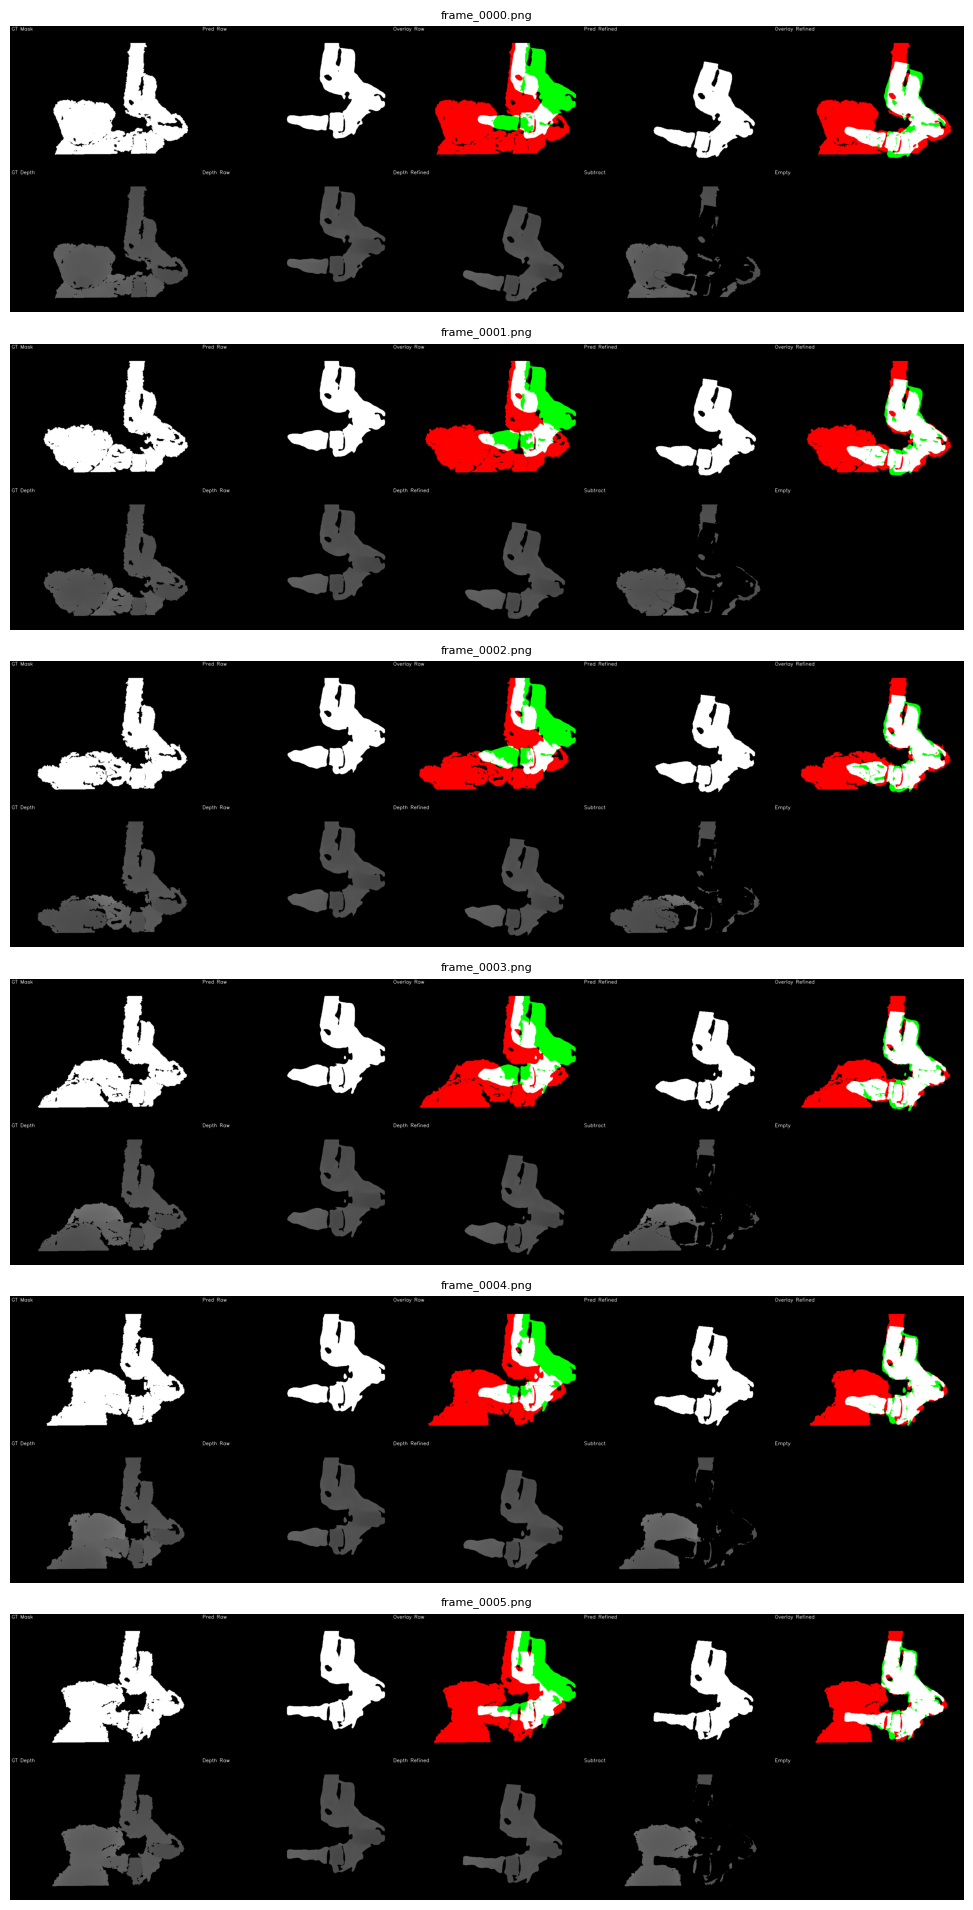

In [ ]:
stage_a_compare_dir = os.path.join(STAGE_A_OUTPUT_DIR, 'comparisons')
sample_files = sorted(glob.glob(os.path.join(stage_a_compare_dir, '*.png')))[:PREVIEW_SAMPLES]
if sample_files:
    fig, axes = plt.subplots(len(sample_files), 1, figsize=(14, len(sample_files) * 3.2))
    if len(sample_files) == 1:
        axes = [axes]
    for ax, fp in zip(axes, sample_files):
        img = cv2.imread(fp)[..., ::-1]
        ax.imshow(img); ax.set_title(os.path.basename(fp), fontsize=8); ax.axis('off')
    plt.tight_layout(); plt.show()
else:
    print('No Stage A compare images found yet.')

## 8. Stage B — vectorized KNN residue cluster filter

Uses `NearestNeighbors.kneighbors_graph(mode='distance')` to build the adjacency in one call (no Python-level edge loop), then thresholds distances sparsely. Scales well at 640×480 where each frame can have tens of thousands of non-zero pixels.

In [ ]:
def knn_keep_largest(depth_u16: np.ndarray, k: int = 5, max_dist_px: float = 4.0):
    """Keep only the largest connected component of a KNN graph on non-zero pixels."""
    ys, xs = np.where(depth_u16 > 0)
    if len(ys) == 0:
        return depth_u16.copy(), {'n_clusters': 0, 'sizes': [], 'kept_size': 0}

    coords = np.column_stack([ys, xs]).astype(np.float32)
    N = len(coords)
    k_actual = min(k + 1, N)  # +1 since kneighbors_graph includes self

    nn = NearestNeighbors(n_neighbors=k_actual, algorithm='kd_tree', metric='euclidean')
    nn.fit(coords)
    knn_graph = nn.kneighbors_graph(coords, n_neighbors=k_actual, mode='distance')

    # Drop long edges (and self-loops which have distance 0).
    knn_graph.data[knn_graph.data > max_dist_px] = 0.0
    knn_graph.eliminate_zeros()
    adj = knn_graph.maximum(knn_graph.T)  # symmetrize

    n_components, labels = csgraph.connected_components(adj, directed=False)
    component_sizes = np.bincount(labels)
    largest_label = int(np.argmax(component_sizes))

    cleaned = np.zeros_like(depth_u16)
    keep = labels == largest_label
    cleaned[ys[keep], xs[keep]] = depth_u16[ys[keep], xs[keep]]

    return cleaned, {
        'n_clusters': int(n_components),
        'sizes'     : sorted(component_sizes.tolist(), reverse=True)[:10],
        'kept_size' : int(component_sizes[largest_label]),
    }

In [ ]:
def run_stage_b():
    input_dir   = os.path.join(STAGE_A_OUTPUT_DIR, 'subtracted_depth_raw')
    gt_mask_dir = os.path.join(STAGE_A_OUTPUT_DIR, 'gt_masks')
    os.makedirs(STAGE_B_OUTPUT_DIR, exist_ok=True)
    cleaned_dir = os.path.join(STAGE_B_OUTPUT_DIR, 'cleaned_depth')
    compare_dir = os.path.join(STAGE_B_OUTPUT_DIR, 'comparisons')
    os.makedirs(cleaned_dir, exist_ok=True)
    if SAVE_COMPARISONS:
        os.makedirs(compare_dir, exist_ok=True)

    input_files = sorted(glob.glob(os.path.join(input_dir, '*.png')))
    print(f'Found {len(input_files)} subtracted depth images in {input_dir}')
    if not input_files:
        return []

    def _norm16(img):
        v = img.astype(np.float32); mx = v.max()
        return np.zeros_like(img, dtype=np.uint8) if mx == 0 else (v / mx * 255).astype(np.uint8)

    stats_rows = []
    for fpath in tqdm(input_files, desc='Stage B'):
        fname = os.path.basename(fpath)
        depth_raw = cv2.imread(fpath, cv2.IMREAD_UNCHANGED)
        if depth_raw is None:
            print(f'  [WARN] could not read {fpath}'); continue

        cleaned, info = knn_keep_largest(depth_raw, k=K_NEIGHBORS, max_dist_px=MAX_DIST_PX)
        cv2.imwrite(os.path.join(cleaned_dir, fname), cleaned)

        stats_rows.append({
            'stem'        : fname,
            'n_clusters'  : info['n_clusters'],
            'kept_px'     : info['kept_size'],
            'total_px'    : int(np.count_nonzero(depth_raw)),
            'removed_px'  : int(np.count_nonzero(depth_raw)) - info['kept_size'],
            'top10_sizes' : str(info['sizes']),
        })

        if SAVE_COMPARISONS:
            gt_path = os.path.join(gt_mask_dir, fname)
            gt_mask = cv2.imread(gt_path, cv2.IMREAD_GRAYSCALE) if os.path.exists(gt_path) else None

            n_cols = 4 if gt_mask is not None else 3
            fig, axes = plt.subplots(1, n_cols, figsize=(n_cols * 3, 3))
            axes[0].imshow(_norm16(depth_raw), cmap='gray')
            axes[0].set_title('Subtracted (input)'); axes[0].axis('off')
            axes[1].imshow(_norm16(cleaned), cmap='gray')
            axes[1].set_title(f"Cleaned\n(kept {info['kept_size']} px)"); axes[1].axis('off')
            residue = depth_raw.copy(); residue[cleaned > 0] = 0
            axes[2].imshow(_norm16(residue), cmap='hot')
            axes[2].set_title(f"Removed residue\n({max(info['n_clusters']-1, 0)} blobs)"); axes[2].axis('off')
            if gt_mask is not None:
                axes[3].imshow(gt_mask, cmap='gray'); axes[3].set_title('GT mask'); axes[3].axis('off')
            plt.suptitle(fname, fontsize=9); plt.tight_layout()
            fig.savefig(os.path.join(compare_dir, fname), dpi=120, bbox_inches='tight')
            plt.close(fig)

    csv_path = os.path.join(STAGE_B_OUTPUT_DIR, 'knn_filter_stats.csv')
    if stats_rows:
        with open(csv_path, 'w', newline='') as f:
            w = csv.DictWriter(f, fieldnames=stats_rows[0].keys())
            w.writeheader(); w.writerows(stats_rows)
        print(f'Stats saved to {csv_path}')
        removed = [r['removed_px'] for r in stats_rows]
        total   = [r['total_px']   for r in stats_rows]
        kept    = [r['kept_px']    for r in stats_rows]
        mean_total = float(np.mean(total)) if total else 0.0
        pct = 100.0 * float(np.mean(removed)) / mean_total if mean_total else 0.0
        print(f'\nSummary over {len(stats_rows)} images:')
        print(f'  avg non-zero before : {mean_total:.0f} px')
        print(f'  avg removed residue : {float(np.mean(removed)):.0f} px  ({pct:.1f}%)')
        print(f'  avg kept            : {float(np.mean(kept)):.0f} px')

    return stats_rows

stage_b_stats = run_stage_b()

Found 24 subtracted depth images in /content/session_test/session_test/test_outputs_mask_depth_refined_640x480/subtracted_depth_raw


Stage B:   0%|          | 0/24 [00:00<?, ?it/s]

Stats saved to /content/session_test/session_test/test_outputs_knn_filtered/knn_filter_stats.csv

Summary over 24 images:
  avg non-zero before : 46519 px
  avg removed residue : 7448 px  (16.0%)
  avg kept            : 39071 px


### 8b. Preview Stage B outputs

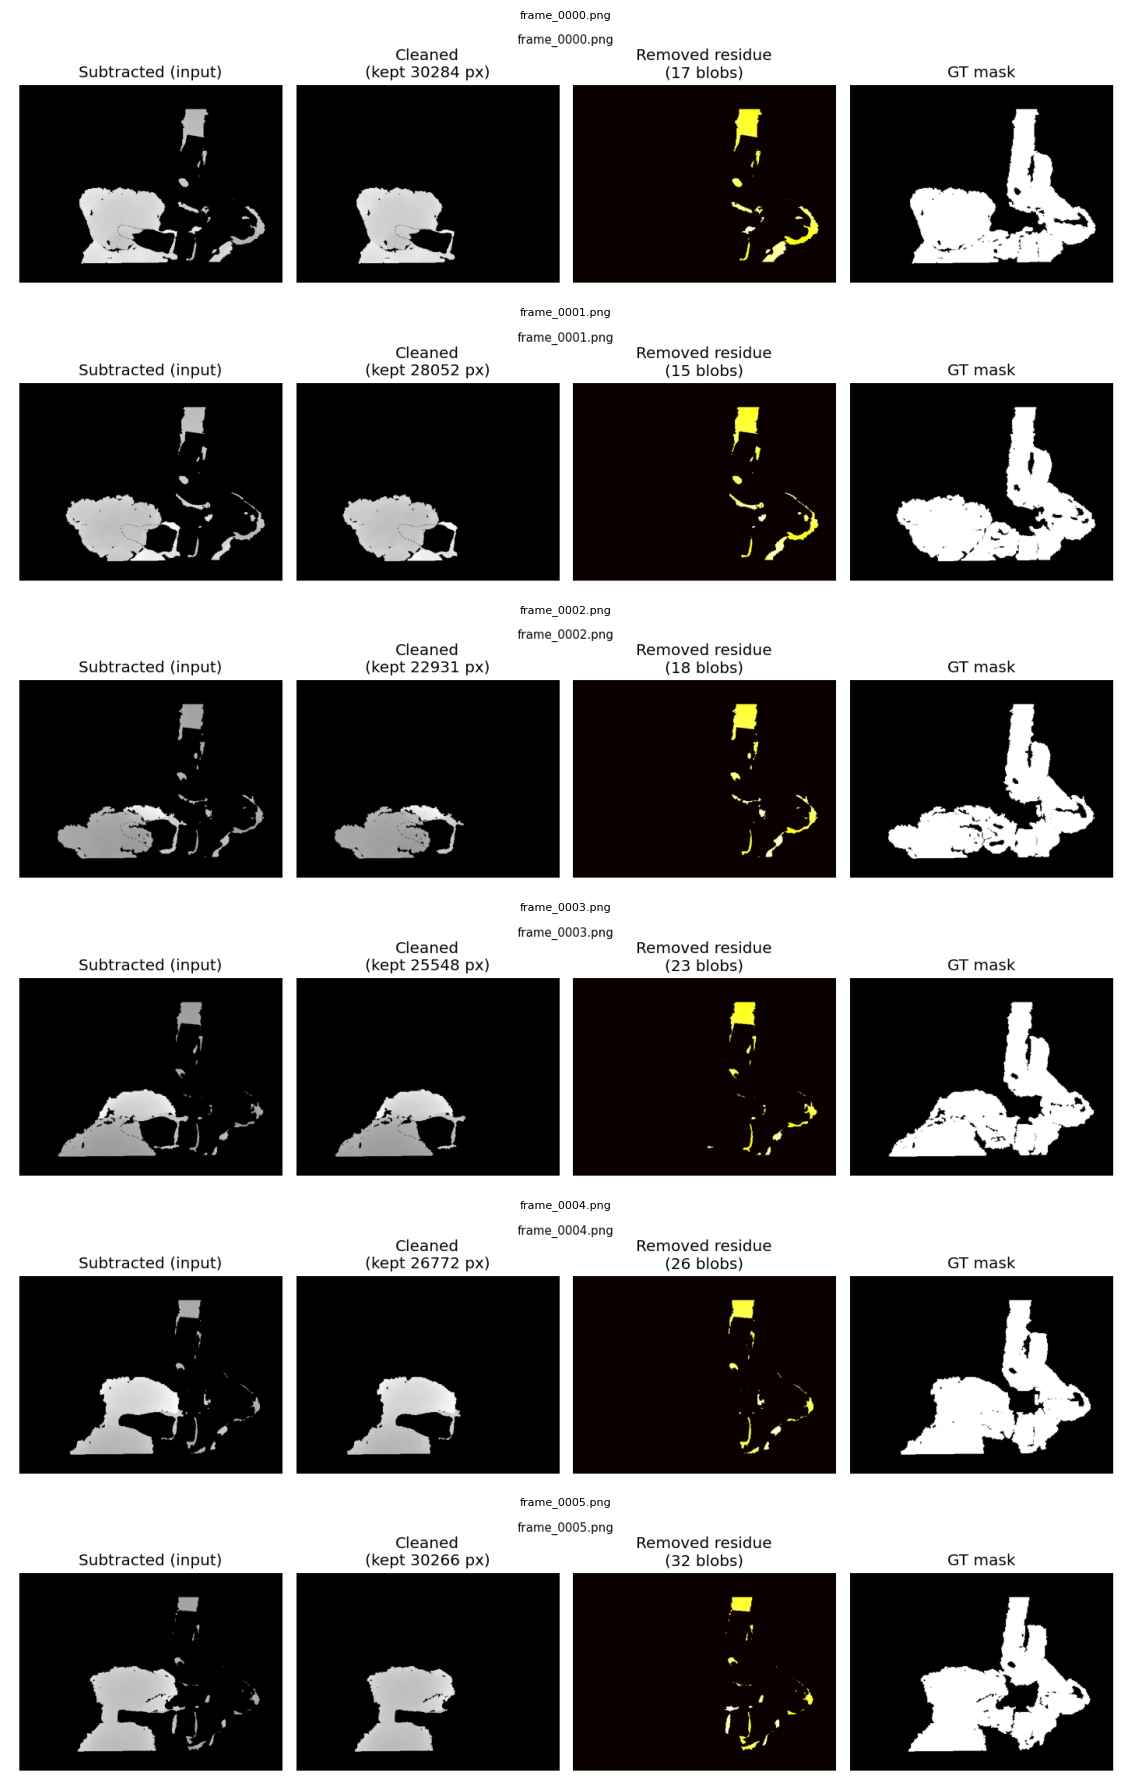

In [ ]:
stage_b_compare_dir = os.path.join(STAGE_B_OUTPUT_DIR, 'comparisons')
sample_files = sorted(glob.glob(os.path.join(stage_b_compare_dir, '*.png')))[:PREVIEW_SAMPLES]
if sample_files:
    fig, axes = plt.subplots(len(sample_files), 1, figsize=(14, len(sample_files) * 3))
    if len(sample_files) == 1:
        axes = [axes]
    for ax, fp in zip(axes, sample_files):
        img = cv2.imread(fp)[..., ::-1]
        ax.imshow(img); ax.set_title(os.path.basename(fp), fontsize=8); ax.axis('off')
    plt.tight_layout(); plt.show()
else:
    print('No Stage B compare images produced.')

## 9. Tuning notes

### Stage A — 640×480 specifics
- `COARSE_DX` / `COARSE_DY` are scaled ~5× vs. 128×128 (±50 / ±40 at step 10). `FINE_DXY_RADIUS = 8`.
- Centroid penalty normalised by `max(H, W) = 640`.
- `close_to_pred` ROI uses a 43×43 dilation kernel.
- Reduce `WARP_CHUNK` (→128, 64) if the GPU OOMs on the fine search.
- If the refinement snaps toward the object, try `OBS_MASK_MODE = 'close_to_pred'`, raise `LAMBDA_CENTER`, or raise `MIN_IOU_IMPROVEMENT_TO_ACCEPT`.

### Stage B — KNN filter
| Parameter | Effect |
|---|---|
| `K_NEIGHBORS`  | More neighbours → harder to split touching blobs. Start at 5. |
| `MAX_DIST_PX`  | Larger gap tolerance → merges close-but-not-touching blobs. Try 2–8 px. |

If residue is **touching** the object, KNN can't separate them — shrink `MAX_DIST_PX`, or post-filter by minimum cluster area.

## TSDF 3D Recontruction

###Setting configuration for using TSDF algorithm


In [ ]:

# ==============================
# SESSION PATH
# ==============================

# SESSION_PATH = "/home/bozznyskrtt/pcl_ws/teddybear/session17/test_outputs_knn_filtered/cleaned_depth"
# DEPTH_PATTERN = "frame_*.png"
# POSE_FOLDER = "poses"

SESSION_PATH = STAGE_B_OUTPUT_DIR + '/cleaned_depth'

DEPTH_PATTERN = "frame_*.png"
POSE_FOLDER = "poses"

OUTPUT_MESH = "tsdf_mesh.ply"
OUTPUT_POINTCLOUD = "tsdf_cloud.ply"

# ==============================
# CAMERA INTRINSICS
# ==============================

WIDTH = 640
HEIGHT = 480

FX = 456.701904296875
FY = 456.701904296875
CX = 331.47186279296875
CY = 242.0

# ==============================
# DEPTH SETTINGS
# ==============================

DEPTH_SCALE = 1000.0      # uint16 depth in mm
DEPTH_TRUNC = 0.8         # meters

# ==============================
# TSDF PARAMETERS
# ==============================

VOXEL_SIZE = 0.003       # 5 mm
SDF_TRUNC = 0.02          # 2 cm

# ==============================
# CROP SETTINGS
# image crop: x_min, y_min, x_max, y_max
# Keep only this box, zero everything else
# ==============================

USE_CROP = False
CROP_X_MIN = 140
CROP_Y_MIN = 120
CROP_X_MAX = 380
CROP_Y_MAX = 410

# Optional depth range crop in meters
USE_DEPTH_RANGE_CROP = False
CROP_DEPTH_MIN_M = 0.20
CROP_DEPTH_MAX_M = 0.80


### Define and running TSDF algorithm


In [ ]:
def crop_depth_image(depth_np: np.ndarray) -> np.ndarray:
    out = depth_np.copy()

    if USE_CROP:
        mask = np.zeros_like(out, dtype=bool)
        mask[CROP_Y_MIN:CROP_Y_MAX, CROP_X_MIN:CROP_X_MAX] = True
        out[~mask] = 0

    if USE_DEPTH_RANGE_CROP:
        depth_m = out.astype(np.float32) / DEPTH_SCALE
        bad = (depth_m < CROP_DEPTH_MIN_M) | (depth_m > CROP_DEPTH_MAX_M)
        out[bad] = 0

    return out


def make_rgbd_from_depth(depth_np: np.ndarray) -> o3d.geometry.RGBDImage:
    depth_img = o3d.geometry.Image(depth_np.astype(np.uint16))
    dummy_color = o3d.geometry.Image(
        np.zeros((HEIGHT, WIDTH, 3), dtype=np.uint8)
    )
    rgbd = o3d.geometry.RGBDImage.create_from_color_and_depth(
        dummy_color,
        depth_img,
        depth_scale=DEPTH_SCALE,
        depth_trunc=DEPTH_TRUNC,
        convert_rgb_to_intensity=False
    )
    return rgbd


def main():
    depth_files = sorted(glob.glob(os.path.join(SESSION_PATH, DEPTH_PATTERN)))
    if len(depth_files) == 0:
        print("No depth images found.")
        return

    poses_dir = os.path.join(SESSION_DIR, POSE_FOLDER)

    intrinsics = o3d.camera.PinholeCameraIntrinsic(
        WIDTH, HEIGHT, FX, FY, CX, CY
    )

    volume = o3d.pipelines.integration.ScalableTSDFVolume(
        voxel_length=VOXEL_SIZE,
        sdf_trunc=SDF_TRUNC,
        color_type=o3d.pipelines.integration.TSDFVolumeColorType.NoColor
    )

    integrated = 0

    for depth_path in depth_files:
        name = os.path.splitext(os.path.basename(depth_path))[0]
        pose_path = os.path.join(poses_dir, f"{name}_T_ee_to_cam.npy")

        if not os.path.exists(pose_path):
            print(f"[SKIP] Missing pose: {pose_path}")
            continue

        # Load pose
        extrinsic = np.linalg.inv(np.load(pose_path))

        # Load and crop depth
        depth_o3d = o3d.io.read_image(depth_path)
        depth_np = np.asarray(depth_o3d)

        if depth_np.dtype != np.uint16:
            depth_np = depth_np.astype(np.uint16)

        depth_np = crop_depth_image(depth_np)

        # Skip empty frames
        if np.count_nonzero(depth_np) < 100:
            print(f"[SKIP] Too few valid pixels after crop: {depth_path}")
            continue

        rgbd = make_rgbd_from_depth(depth_np)

        # Integrate
        volume.integrate(rgbd, intrinsics, extrinsic)
        integrated += 1

        if integrated % 10 == 0:
            print(f"Integrated {integrated} frames")

    print(f"Total integrated: {integrated}")

    if integrated == 0:
        print("No frames integrated.")
        return

    # ==============================
    # Extract mesh
    # ==============================
    mesh = volume.extract_triangle_mesh()
    mesh.compute_vertex_normals()

    mesh_path = os.path.join(SESSION_DIR, OUTPUT_MESH)
    o3d.io.write_triangle_mesh(mesh_path, mesh)
    print(f"Mesh saved to: {mesh_path}")

    # ==============================
    # Extract point cloud
    # ==============================
    pcd = volume.extract_point_cloud()

    # # Optional cleanup
    # if len(pcd.points) > 0:
    #     pcd = pcd.voxel_down_sample(voxel_size=0.0005)

    pcd_path = os.path.join(SESSION_DIR, OUTPUT_POINTCLOUD)
    o3d.io.write_point_cloud(pcd_path, pcd)
    print(f"Point cloud saved to: {pcd_path}")

    # Optional preview
    # o3d.visualization.draw_geometries([mesh])
    # o3d.visualization.draw_geometries([pcd])


if __name__ == "__main__":
    main()

Integrated 10 frames
Integrated 20 frames
Total integrated: 24
Mesh saved to: /content/session_test/session_test/tsdf_mesh.ply
Point cloud saved to: /content/session_test/session_test/tsdf_cloud.ply


###Visualization

In [ ]:
import plotly.graph_objects as go

print("Load a ply point cloud, print it, and render it")
ply_point_cloud = o3d.data.PLYPointCloud()
pcd = o3d.io.read_point_cloud('/content/session_test/session_test/tsdf_cloud.ply')
points = np.asarray(pcd.points)
print(pcd)
print(np.asarray(pcd.points))

colors = None
if pcd.has_colors():
    colors = np.asarray(pcd.colors)
elif pcd.has_normals():
    colors = (0.5, 0.5, 0.5) + np.asarray(pcd.normals) * 0.5

fig = go.Figure(
  data=[
    go.Scatter3d(
      x=points[:,0], y=points[:,1], z=points[:,2],
      mode='markers',
      marker=dict(size=1, color=colors)
)
],
  layout=dict(
    scene=dict(
      xaxis=dict(visible=False),
      yaxis=dict(visible=False),
      zaxis=dict(visible=False)
)
)
)
fig.show()

Load a ply point cloud, print it, and render it
[Open3D INFO] Downloading https://github.com/isl-org/open3d_downloads/releases/download/20220201-data/fragment.ply
[Open3D INFO] Downloaded to /root/open3d_data/download/PLYPointCloud/fragment.ply
PointCloud with 27278 points.
[[ 0.00192636  0.0015     -0.0795    ]
 [ 0.0015      0.00216368 -0.0795    ]
 [ 0.00357712  0.0015     -0.0765    ]
 ...
 [ 0.0465     -0.07613569 -0.0465    ]
 [ 0.0465     -0.06573211 -0.0465    ]
 [ 0.0465     -0.06204889 -0.0465    ]]


If it said web-GL not support

1. go to chrome://gpu and check on WebGL
2. go to chrome://flags enable override software accelerating list
<br>
else:
<br>
  update your greaphics driver

The Point cloud and mesh files needs to be open in a specific programs called **Meshlab**, if you don't have one download it.

for linux:
```bash
sudo apt install meshlab
```
for windows & macOS:\
https://www.meshlab.net/
\
\
\
**Have fun with AI** <br>
**Supphasan Saithong**